<a href="https://colab.research.google.com/github/Vaishnavi688/Movie-recommendation-system/blob/main/ML_Movie_Recommedation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ratings = pd.read_csv('/content/drive/MyDrive/MovieRecommodation/ratings.csv')
movies = pd.read_csv('/content/drive/MyDrive/MovieRecommodation/movies.csv')

In [5]:
print("Ratings columns:", ratings.columns)
print("Movies columns:", movies.columns)

print(movies.head())
print(ratings.head())

Ratings columns: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Movies columns: Index(['movieId', 'title', 'genres'], dtype='object')
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205


In [6]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

Ratings Shape: (100004, 4)
Movies Shape: (9125, 3)


In [7]:
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [8]:
data = pd.merge(ratings, movies, on='movieId')

print(data.head())


   userId  movieId  rating   timestamp  \
0       1       31     2.5  1260759144   
1       1     1029     3.0  1260759179   
2       1     1061     3.0  1260759182   
3       1     1129     2.0  1260759185   
4       1     1172     4.0  1260759205   

                                            title  \
0                          Dangerous Minds (1995)   
1                                    Dumbo (1941)   
2                                 Sleepers (1996)   
3                     Escape from New York (1981)   
4  Cinema Paradiso (Nuovo cinema Paradiso) (1989)   

                             genres  
0                             Drama  
1  Animation|Children|Drama|Musical  
2                          Thriller  
3  Action|Adventure|Sci-Fi|Thriller  
4                             Drama  


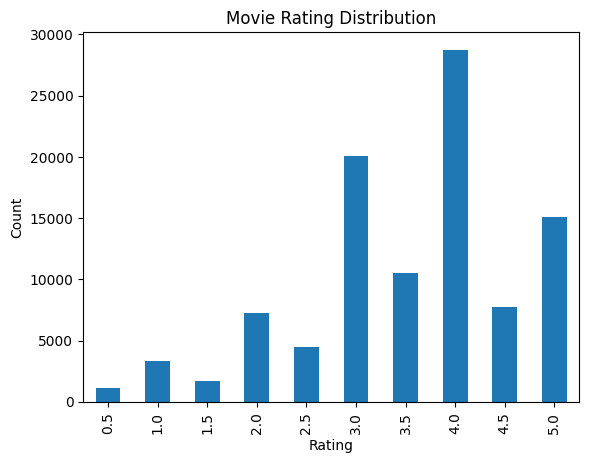

In [9]:
#rating distribution graph
import matplotlib.pyplot as plt

ratings['rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

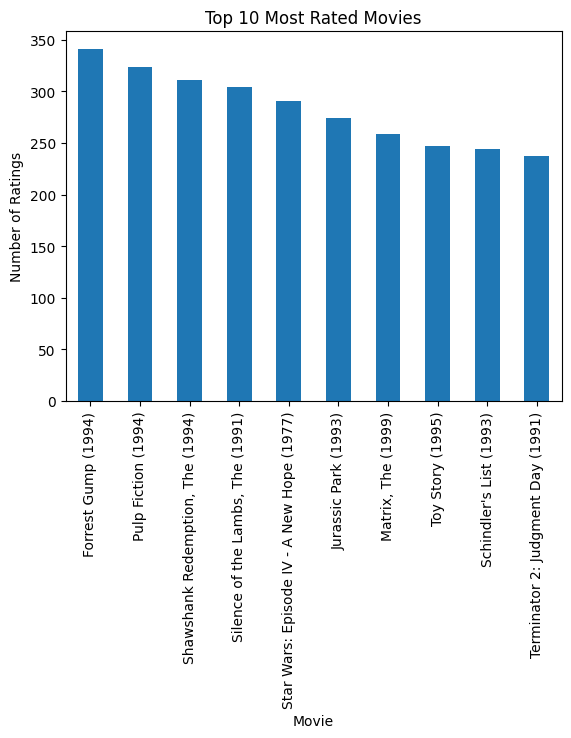

In [10]:
#Top rated movies graph
top_movies = data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

top_movies.plot(kind='bar')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=90)
plt.show()

In [11]:
user_item_matrix = data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

user_item_matrix.fillna(0, inplace=True)

print(user_item_matrix.shape)
print(user_item_matrix.head())

(671, 9064)
title   "Great Performances" Cats (1998)  $9.99 (2008)  \
userId                                                   
1                                    0.0           0.0   
2                                    0.0           0.0   
3                                    0.0           0.0   
4                                    0.0           0.0   
5                                    0.0           0.0   

title   'Hellboy': The Seeds of Creation (2004)  \
userId                                            
1                                           0.0   
2                                           0.0   
3                                           0.0   
4                                           0.0   
5                                           0.0   

title   'Neath the Arizona Skies (1934)  'Round Midnight (1986)  \
userId                                                            
1                                   0.0                     0.0   
2                     

In [12]:
#Train knn model
model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(user_item_matrix)


NearestNeighbors(algorithm='brute', metric='cosine')

In [13]:
#Similar User
query_index = 0

distances, indices = model.kneighbors(
    user_item_matrix.iloc[query_index, :].values.reshape(1, -1),
    n_neighbors=6
)

print("Similar Users:\n")

for i in range(len(indices.flatten())):
    print(
        "User:",
        indices.flatten()[i] + 1,
        "Distance:",
        round(distances.flatten()[i], 4)
    )

Similar Users:

User: 1 Distance: 0.0
User: 325 Distance: 0.6281
User: 634 Distance: 0.8059
User: 341 Distance: 0.8372
User: 310 Distance: 0.8425
User: 207 Distance: 0.8473


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [14]:
#Creating Recommendation Function
def recommend_movies(user_id, n_recommendations=10):

    user_index = user_id - 1

    distances, indices = model.kneighbors(
        user_item_matrix.iloc[user_index, :].values.reshape(1, -1),
        n_neighbors=6
    )

    similar_users = indices.flatten()[1:]

    similar_user_ratings = user_item_matrix.iloc[similar_users]

    avg_ratings = similar_user_ratings.mean(axis=0)

    watched_movies = user_item_matrix.iloc[user_index]

    recommendations = avg_ratings[watched_movies == 0]

    recommendations = recommendations.sort_values(
        ascending=False
    ).head(n_recommendations)

    return recommendations


In [15]:
#Genrating Recommendations
recommendations = recommend_movies(1)

print("Recommended Movies:\n")

for movie, score in recommendations.items():
    print(movie)

Recommended Movies:

Beverly Hills Cop (1984)
Junior (1994)
Shawshank Redemption, The (1994)
Fargo (1996)
Proof (2005)
Brady Bunch Movie, The (1995)
Ronin (1998)
Godfather, The (1972)
Godfather: Part II, The (1974)
Ali G Indahouse (2002)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [16]:
#Movie to Movie Recommendation
recommendations = recommend_movies(1)

print("Recommended Movies:\n")

for movie, score in recommendations.items():
    print(movie)

Recommended Movies:

Beverly Hills Cop (1984)
Junior (1994)
Shawshank Redemption, The (1994)
Fargo (1996)
Proof (2005)
Brady Bunch Movie, The (1995)
Ronin (1998)
Godfather, The (1972)
Godfather: Part II, The (1974)
Ali G Indahouse (2002)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [17]:
movie_matrix = data.pivot_table(
    index='title',
    columns='userId',
    values='rating'
)

movie_matrix.fillna(0, inplace=True)

print(movie_matrix.shape)

(9064, 671)


In [18]:
movie_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

movie_model.fit(movie_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [19]:
#creating movie Recommendation
def similar_movies(movie_name):

    movie_index = movie_matrix.index.get_loc(movie_name)

    distances, indices = movie_model.kneighbors(
        movie_matrix.iloc[movie_index, :]
        .values.reshape(1, -1),
        n_neighbors=6
    )

    print("Movies similar to:", movie_name)

    for i in range(1, len(indices.flatten())):
        print(
            movie_matrix.index[
                indices.flatten()[i]
            ]
        )

In [20]:
similar_movies("Toy Story (1995)")

Movies similar to: Toy Story (1995)
Toy Story 2 (1999)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)
Independence Day (a.k.a. ID4) (1996)
Groundhog Day (1993)
